In [1]:
import torch
from torchvision.transforms import ToTensor
from torchvision import datasets
import torch.nn as nn # nueral network
import torch.optim as optim # optimizer
from torch.utils.data import TensorDataset, DataLoader


In [3]:
# 학습 데이터 불러오기
train_data = datasets.FashionMNIST(
    root='../Data',
    train = True,
    download = True,
    transform = ToTensor()
)



In [4]:
# 테스트 데이터 불러오기
test_data = datasets.FashionMNIST(
    root='../Data',
    train = False,
    download = True,
    transform = ToTensor()
)

In [5]:
# 받은 데이터 확인
print(train_data.data.shape)
print(train_data.targets.shape)
print(test_data.data.shape)
print(test_data.targets.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])
torch.Size([10000, 28, 28])
torch.Size([10000])


In [6]:
# Train data를 훈련 데이터와 검증 데이터로 나누기

from sklearn.model_selection import train_test_split

train_input = train_data.data.unsqueeze(1).float() / 255.0 # 채널 차원 추가 및 정규화
train_target = train_data.targets

test_input = test_data.data.unsqueeze(1).float() / 255.0
test_target = test_data.targets

train_input, val_input, train_target, val_target = train_test_split(
    train_input,
    train_target,
    test_size=0.2,
    random_state=42
)

In [7]:
# Dimension

print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

torch.Size([48000, 1, 28, 28]) torch.Size([48000])
torch.Size([10000, 1, 28, 28]) torch.Size([10000])


----
#### CNN 신경망 만들기

In [8]:
# DataSet과 DataLoader 생성

batch_size = 32 # mini batch. 전체를 안 쓰고 32개씩 불러서 처리한다.

train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input, val_target)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


#### 모델 정의

In [9]:
class CNNModel(nn.Module):

    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)    
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # maxpool은 서로 곂치면 안 되므로 stride를 2로 주어 곂치지 않게 한다.
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)    
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128) # 7은 28을 maxpooling을 두 번 했으므로 28 / 2 / 2를 하여 7이 나오는거
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 10) 
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x


In [ ]:
# device = torch.device("mps" if torch.backends.mps.is_available() else 'cpu')
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

model = CNNModel().to(device) # 시작을 원래 여기서부터 해줘야 한다 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

----
#### 모델 훈련

In [24]:
# 학습 함수
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

    return loss.item()    


In [25]:
# 평가 함수
def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0 # 전체 손실 합계
    correct = 0 # 정확하게 예측한 샘플 수
    total = 0 # 전체 샘플 수
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            _, predict = outputs.max(1)
            total += targets.size(0)
            correct += predict.eq(targets).sum().item()

    return total_loss / len(val_loader), correct / total # 평균 손실, 정확도


In [26]:
# 예측 함수
def predict(model, data_loader, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            predictions.extend(predicted.cpu().numpy()) # gpu를 사용할 경우 gpu에선 계산만 할 수 있고 화면에 출력할 수 없기 때문에 cpu로 전달하는 과정을 거쳐야 한다.
        return predictions    

In [27]:
# 훈련하기

num_epoches = 50
train_loss_scores = []
val_loss_scores = []

for epoch in range(num_epoches):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuarcy = evaluate(model, val_loader, criterion, device)
    train_loss_scores.append(train_loss)
    val_loss_scores.append(val_loss)
    print(f'Epoch [{epoch + 1:>3} / {num_epoches}], Loss : {train_loss:.4f}, Val_loss : {val_loss:.4f}, Val_accuarcy : {val_accuarcy:.4f}')

Epoch [  1 / 50], Loss : 1.5953, Val_loss : 1.6156, Val_accuarcy : 0.8467
Epoch [  2 / 50], Loss : 1.5481, Val_loss : 1.5947, Val_accuarcy : 0.8661
Epoch [  3 / 50], Loss : 1.5234, Val_loss : 1.5815, Val_accuarcy : 0.8801
Epoch [  4 / 50], Loss : 1.5850, Val_loss : 1.5831, Val_accuarcy : 0.8778
Epoch [  5 / 50], Loss : 1.6279, Val_loss : 1.5726, Val_accuarcy : 0.8882
Epoch [  6 / 50], Loss : 1.5570, Val_loss : 1.5668, Val_accuarcy : 0.8952
Epoch [  7 / 50], Loss : 1.5798, Val_loss : 1.5681, Val_accuarcy : 0.8930
Epoch [  8 / 50], Loss : 1.6037, Val_loss : 1.5611, Val_accuarcy : 0.8996
Epoch [  9 / 50], Loss : 1.4944, Val_loss : 1.5598, Val_accuarcy : 0.9005
Epoch [ 10 / 50], Loss : 1.6446, Val_loss : 1.5563, Val_accuarcy : 0.9047
Epoch [ 11 / 50], Loss : 1.5137, Val_loss : 1.5552, Val_accuarcy : 0.9060
Epoch [ 12 / 50], Loss : 1.5878, Val_loss : 1.5570, Val_accuarcy : 0.9027
Epoch [ 13 / 50], Loss : 1.5237, Val_loss : 1.5541, Val_accuarcy : 0.9071
Epoch [ 14 / 50], Loss : 1.5549, Val_l

In [28]:
import matplotlib.pyplot as plt

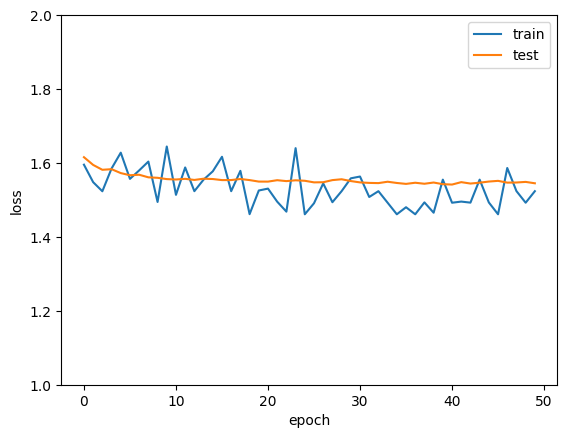

In [29]:
# 시각화 해보기
plt.plot(train_loss_scores)
plt.plot(val_loss_scores)
plt.xlabel('epoch')
plt.ylabel('loss')
# plt.ylim([0,2])
plt.ylim([1,2])
plt.legend(['train','test'])
plt.show()

In [30]:
# 훈련 평가
train_loss, train_accuracy = evaluate(model, train_loader, criterion, device)
print(f'Loss : {train_loss}, Accuracy : {train_accuracy}')

# 검증 평가
val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
print(f'Loss : {val_loss}, Accuracy : {val_accuracy}')

# 테스트 평가
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f'Loss : {test_loss}, Accuracy : {test_accuracy}')

Loss : 1.509165323416392, Accuracy : 0.9518958333333334
Loss : 1.5450167690912882, Accuracy : 0.9160833333333334
Loss : 1.5522559077594988, Accuracy : 0.9089


----
#### 학습한 모델 저장하기


In [20]:
torch.save(model, '../Data/cnn_fsmist.pth') # pytorch는 확장자가 pth


In [21]:
# 전체 모델 불러오기
model1 = torch.load('../Data/cnn_fsmist.pth', weights_only=False)

----
#### Image만들어서 예측해보기

In [23]:
from PIL import Image
import numpy as np

In [25]:
# train data의 50번째 
abc = np.array(train_data.data[50]).reshape(28,28)
abc.shape

/var/folders/g5/4_mh2_1s6xlbwfqnqzhtpxhm0000gn/T/ipykernel_5993/650005900.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  abc = np.array(train_data.data[50]).reshape(28,28)


(28, 28)

In [27]:
# Image 만들기
image = Image.fromarray(abc)
image

In [28]:
# Image 저장
image.save('../Data/fashion_mnist_50.png')

----
#### Image를 불러서 예측

In [29]:
img = Image.open('../Data/fashion_mnist_50.png')
img

In [ ]:
# Image를 numpy array로 변경
img = np.array(img)
img = torch.from_numpy(img)
img.shape

torch.Size([28, 28])

In [ ]:
# 채널 차원 추가 및 정규화
img = img.unsqueeze(0).float() / 255.0
img.shape

torch.Size([1, 28, 28])

In [36]:
# class들의 이름 정의
classes = ['티셔츠', '바지','스웨터', '드레스','코트','샌들','셔츠','스니커즈','가방','앵글 부츠']

In [39]:
# 단일 데이터 예측 함수
def predictOne(model, image, device, classes):
    model.eval()
    with torch.no_grad():
        # for inputs, _ in data_loader:
        image = image.to(device)
        outputs = model(image.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)
        predicted_classes = classes[predicted.item()]
    return predicted_classes 

In [40]:
predictOne(model, img, device, classes)

'드레스'